In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
data = {
    "Order_ID": [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010,
                 1011, 1012, 1013, 1014, 1015],
    "Order_Date": ["2026-01-05", "2026-01-08", "2026-01-15", "2026-02-02", "2026-02-10",
                   "2026-02-18", "2026-03-01", "2026-03-12", "2026-03-20", "2026-04-05",
                   "2026-04-15", "2026-05-03", "2026-05-18", "2026-06-07", "2026-06-20"],
    "Product": ["Laptop", "Mouse", "Keyboard", "Laptop", "Monitor",
                 "Mouse", "Laptop", "Keyboard", "Monitor", "Laptop",
                 "Mouse", "Monitor", "Keyboard", "Laptop", "Mouse"],
    "Region": ["South", "North", "South", "West", "North",
               "South", "West", "South", None, "North",
               "West", "South", "North", "West", "South"],
    "Quantity": [2, 10, 5, 1, 3, 15, 2, 8, None, 1,
                 20, 4, 6, 2, 12],
    "Unit_Price": [55000, 800, 1500, 55000, 18000,
                   800, 55000, 1500, 18000, 55000,
                   800, 18000, 1500, 55000, 800],
    "Customer_Type": ["Corporate", "Individual", "Individual", "Corporate", "Corporate",
                      "Individual", "Corporate", "Individual", "Corporate", "Corporate",
                      "Individual", "Corporate", "Individual", "Corporate", "Individual"]
}

df = pd.DataFrame(data)

print(df)

    Order_ID  Order_Date   Product Region  Quantity  Unit_Price Customer_Type
0       1001  2026-01-05    Laptop  South       2.0       55000     Corporate
1       1002  2026-01-08     Mouse  North      10.0         800    Individual
2       1003  2026-01-15  Keyboard  South       5.0        1500    Individual
3       1004  2026-02-02    Laptop   West       1.0       55000     Corporate
4       1005  2026-02-10   Monitor  North       3.0       18000     Corporate
5       1006  2026-02-18     Mouse  South      15.0         800    Individual
6       1007  2026-03-01    Laptop   West       2.0       55000     Corporate
7       1008  2026-03-12  Keyboard  South       8.0        1500    Individual
8       1009  2026-03-20   Monitor    NaN       NaN       18000     Corporate
9       1010  2026-04-05    Laptop  North       1.0       55000     Corporate
10      1011  2026-04-15     Mouse   West      20.0         800    Individual
11      1012  2026-05-03   Monitor  South       4.0       18000 

In [18]:
df.isnull().sum()

Order_ID         0
Order_Date       0
Product          0
Region           1
Quantity         1
Unit_Price       0
Customer_Type    0
dtype: int64

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       15 non-null     int64  
 1   Order_Date     15 non-null     str    
 2   Product        15 non-null     str    
 3   Region         14 non-null     str    
 4   Quantity       14 non-null     float64
 5   Unit_Price     15 non-null     int64  
 6   Customer_Type  15 non-null     str    
dtypes: float64(1), int64(2), str(4)
memory usage: 972.0 bytes


In [20]:
df['Region'] = df['Region'].fillna(df['Region'].mode()[0])
df['Region']

0     South
1     North
2     South
3      West
4     North
5     South
6      West
7     South
8     South
9     North
10     West
11    South
12    North
13     West
14    South
Name: Region, dtype: str

In [21]:
df['Quantity']= df['Quantity'].fillna(df['Quantity'].median())
df['Quantity']

0      2.0
1     10.0
2      5.0
3      1.0
4      3.0
5     15.0
6      2.0
7      8.0
8      4.5
9      1.0
10    20.0
11     4.0
12     6.0
13     2.0
14    12.0
Name: Quantity, dtype: float64

In [22]:
df.drop_duplicates(subset='Order_ID')

,Order_ID,Order_Date,Product,Region,Quantity,Unit_Price,Customer_Type
0,1001,2026-01-05,Laptop,South,2.0,55000,Corporate
1,1002,2026-01-08,Mouse,North,10.0,800,Individual
2,1003,2026-01-15,Keyboard,South,5.0,1500,Individual
3,1004,2026-02-02,Laptop,West,1.0,55000,Corporate
4,1005,2026-02-10,Monitor,North,3.0,18000,Corporate
5,1006,2026-02-18,Mouse,South,15.0,800,Individual
6,1007,2026-03-01,Laptop,West,2.0,55000,Corporate
7,1008,2026-03-12,Keyboard,South,8.0,1500,Individual
8,1009,2026-03-20,Monitor,South,4.5,18000,Corporate
9,1010,2026-04-05,Laptop,North,1.0,55000,Corporate


In [23]:
df['Total_Revenue'] = df['Quantity']* df['Unit_Price']
df['Total_Revenue'] 

0     110000.0
1       8000.0
2       7500.0
3      55000.0
4      54000.0
5      12000.0
6     110000.0
7      12000.0
8      81000.0
9      55000.0
10     16000.0
11     72000.0
12      9000.0
13    110000.0
14      9600.0
Name: Total_Revenue, dtype: float64

In [24]:
df[df['Total_Revenue']>10000.0]

,Order_ID,Order_Date,Product,Region,Quantity,Unit_Price,Customer_Type,Total_Revenue
0,1001,2026-01-05,Laptop,South,2.0,55000,Corporate,110000.0
3,1004,2026-02-02,Laptop,West,1.0,55000,Corporate,55000.0
4,1005,2026-02-10,Monitor,North,3.0,18000,Corporate,54000.0
5,1006,2026-02-18,Mouse,South,15.0,800,Individual,12000.0
6,1007,2026-03-01,Laptop,West,2.0,55000,Corporate,110000.0
7,1008,2026-03-12,Keyboard,South,8.0,1500,Individual,12000.0
8,1009,2026-03-20,Monitor,South,4.5,18000,Corporate,81000.0
9,1010,2026-04-05,Laptop,North,1.0,55000,Corporate,55000.0
10,1011,2026-04-15,Mouse,West,20.0,800,Individual,16000.0
11,1012,2026-05-03,Monitor,South,4.0,18000,Corporate,72000.0


In [25]:
df.groupby('Region')['Total_Revenue'].agg(['sum', 'mean'])

,sum,mean
Region,,
North,126000.0,31500.000000
South,304100.0,43442.857143
West,291000.0,72750.000000


In [26]:
df['Total_Revenue'].sort_values(ascending=False).head()

0     110000.0
6     110000.0
13    110000.0
8      81000.0
11     72000.0
Name: Total_Revenue, dtype: float64

<Axes: ylabel='Total_Revenue'>

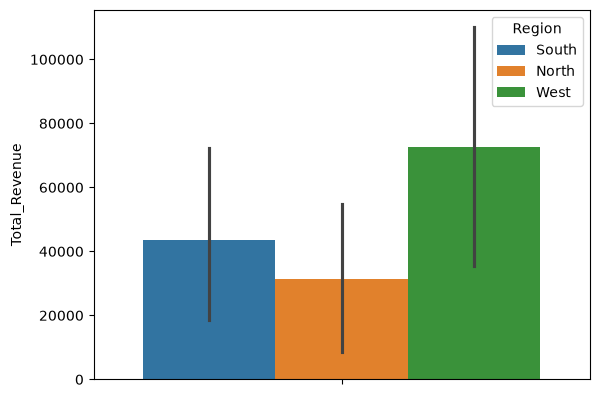

In [27]:
sns.barplot(hue=df['Region'], y=df['Total_Revenue'])

In [29]:
df['order_month']=pd.to_datetime(df['Order_Date']).dt.month

<Axes: xlabel='order_month', ylabel='Total_Revenue'>

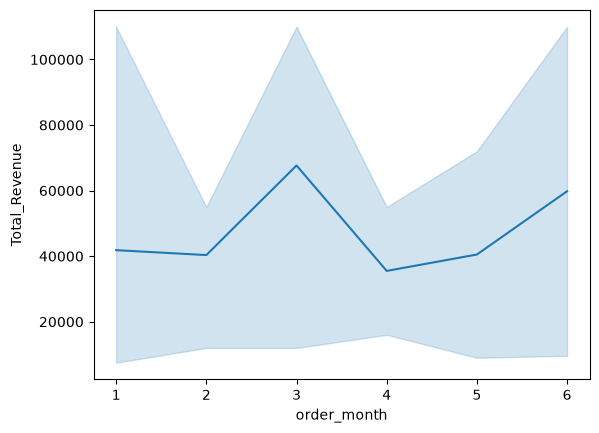

In [30]:
sns.lineplot(x=df['order_month'], y=df['Total_Revenue'])